In [1]:
# ============================================
# DELHIVERY SUPPLY CHAIN DELAY ANALYZER
# Dataset: Delhivery Logistics Data (Kaggle)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# Load the dataset
df = pd.read_csv('../data/raw/delhivery_data.csv')

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape: (144867, 24)

Columns:
['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


In [ ]:
# Peeking at data
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.00,True,9,2018-09-20 04:27:55,10.44,14.00,11.00,11.97,1.27,14.00,11.00,11.97,1.27
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.00,True,18,2018-09-20 04:17:55,18.94,24.00,20.00,21.72,1.20,10.00,9.00,9.76,1.11
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.00,True,27,2018-09-20 04:01:19.505586,27.64,40.00,28.00,32.54,1.43,16.00,7.00,10.82,2.29
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.00,True,36,2018-09-20 03:39:57,36.12,62.00,40.00,45.56,1.55,21.00,12.00,13.02,1.75
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.00,False,39,2018-09-20 03:33:55,39.39,68.00,44.00,54.22,1.55,6.00,5.00,3.92,1.20


In [ ]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DATA TYPES ===
data                                  str
trip_creation_time                    str
route_schedule_uuid                   str
route_type                            str
trip_uuid                             str
source_center                         str
source_name                           str
destination_center                    str
destination_name                      str
od_start_time                         str
od_end_time                           str
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                      str
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
segment_factor 

In [ ]:
# ============================================
# PHASE 2: DATA CLEANING
# ============================================

# 1. Drop rows with missing source/destination (only ~550 rows, safe to drop)
df.dropna(subset=['source_name', 'destination_name'], inplace=True)

# 2. Convert datetime columns
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])

# 3. Drop rows where actual_time or osrm_time is missing or zero
df = df[df['actual_time'] > 0]
df = df[df['osrm_time'] > 0]

print(f"✅ Clean dataset shape: {df.shape}")
print(f"Date range: {df['trip_creation_time'].min()} → {df['trip_creation_time'].max()}")

✅ Clean dataset shape: (144316, 24)
Date range: 2018-09-12 00:00:16.535741 → 2018-10-03 23:59:42.701692


In [ ]:
# ============================================
# PHASE 2: FEATURE ENGINEERING
# ============================================

# 1. Extract STATE from source_name and destination_name
# Names look like: "Anand_VUNagar_DC (Gujarat)" — state is inside brackets
df['source_state'] = df['source_name'].str.extract(r'\(([^)]+)\)')
df['destination_state'] = df['destination_name'].str.extract(r'\(([^)]+)\)')

# 2. Delay in minutes = actual_time - osrm_time
df['delay_minutes'] = df['actual_time'] - df['osrm_time']

# 3. Delay flag — was it delayed? (actual > osrm by more than 10 mins)
df['is_delayed'] = df['delay_minutes'] > 10

# 4. Delay ratio — how much longer than expected?
df['delay_ratio'] = (df['actual_time'] / df['osrm_time']).round(2)

# 5. Time features from trip creation
df['hour'] = df['trip_creation_time'].dt.hour
df['day_of_week'] = df['trip_creation_time'].dt.day_name()
df['month'] = df['trip_creation_time'].dt.month
df['month_name'] = df['trip_creation_time'].dt.month_name()

# 6. Peak season flag (Oct-Dec = Diwali/festive season in India)
df['is_peak_season'] = df['month'].isin([10, 11, 12])

# 7. Is it a weekend?
df['is_weekend'] = df['trip_creation_time'].dt.dayofweek >= 5

# 8. Route label (for easy reading)
df['route'] = df['source_state'] + ' → ' + df['destination_state']

print("✅ Feature engineering complete!")
print(f"\nNew columns added: delay_minutes, is_delayed, delay_ratio,")
print(f"source_state, destination_state, hour, day_of_week,")
print(f"month, is_peak_season, is_weekend, route")

# Quick sanity check
print(f"\n📊 Delayed trips: {df['is_delayed'].sum():,} ({df['is_delayed'].mean()*100:.1f}%)")
print(f"📊 On-time trips: {(~df['is_delayed']).sum():,} ({(~df['is_delayed']).mean()*100:.1f}%)")
print(f"📊 Avg delay: {df['delay_minutes'].mean():.1f} minutes")
print(f"📊 Route types: {df['route_type'].value_counts().to_dict()}")

✅ Feature engineering complete!

New columns added: delay_minutes, is_delayed, delay_ratio,
source_state, destination_state, hour, day_of_week,
month, is_peak_season, is_weekend, route

📊 Delayed trips: 127,022 (88.0%)
📊 On-time trips: 17,294 (12.0%)
📊 Avg delay: 203.6 minutes
📊 Route types: {'FTL': 99132, 'Carting': 45184}


In [ ]:
# Save cleaned data for SQL analysis later
df.to_csv('../data/raw/delhivery_clean.csv', index=False)
print("✅ Clean file saved as delhivery_clean.csv")
print(f"Final shape: {df.shape}")

✅ Clean file saved as delhivery_clean.csv
Final shape: (144316, 36)


###  =============  EDA  ==================


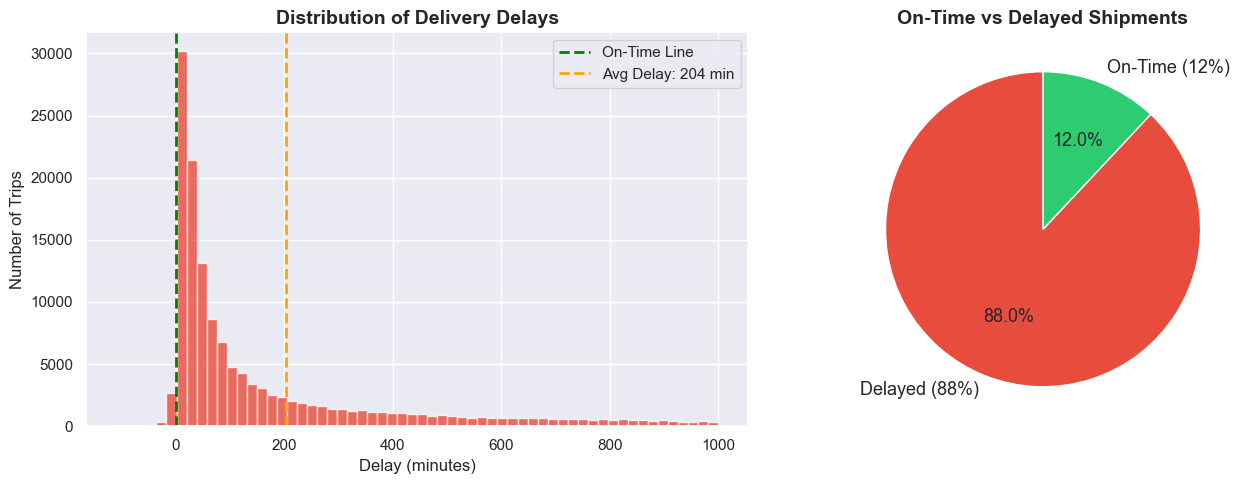

✅ Chart 1 saved!


In [ ]:
# ============================================
# PHASE 3: EXPLORATORY DATA ANALYSIS
# ============================================

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# --- CHART 1: Delay Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap at 1000 mins for readable chart (removes extreme outliers visually)
delay_capped = df[df['delay_minutes'].between(-200, 1000)]['delay_minutes']

axes[0].hist(delay_capped, bins=60, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='green', linestyle='--', linewidth=2, label='On-Time Line')
axes[0].axvline(df['delay_minutes'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Avg Delay: {df["delay_minutes"].mean():.0f} min')
axes[0].set_title('Distribution of Delivery Delays', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Number of Trips')
axes[0].legend()

# --- CHART 2: On-Time vs Delayed Pie ---
labels = ['Delayed (88%)', 'On-Time (12%)']
sizes = [df['is_delayed'].sum(), (~df['is_delayed']).sum()]
colors = ['#E74C3C', '#2ECC71']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('On-Time vs Delayed Shipments', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('../data/raw/chart1_delay_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

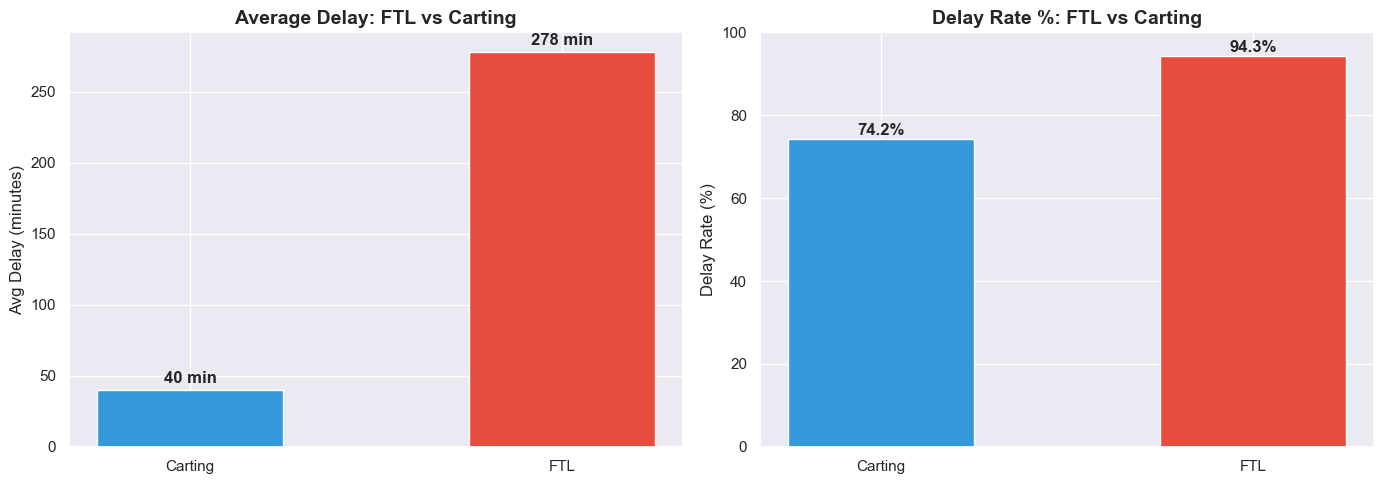

✅ Chart 2 saved!


In [ ]:
# --- CHART 3: FTL vs Carting Delay Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average delay by route type
route_delay = df.groupby('route_type')['delay_minutes'].mean().reset_index()
route_delay.columns = ['Route Type', 'Avg Delay (mins)']

bars = axes[0].bar(route_delay['Route Type'], route_delay['Avg Delay (mins)'],
                    color=['#3498DB', '#E74C3C'], width=0.5, edgecolor='white')
axes[0].set_title('Average Delay: FTL vs Carting', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Avg Delay (minutes)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{bar.get_height():.0f} min', ha='center', fontweight='bold')

# Delay rate by route type
delay_rate = df.groupby('route_type')['is_delayed'].mean().reset_index()
delay_rate['is_delayed'] = delay_rate['is_delayed'] * 100
bars2 = axes[1].bar(delay_rate['route_type'], delay_rate['is_delayed'],
                     color=['#3498DB', '#E74C3C'], width=0.5, edgecolor='white')
axes[1].set_title('Delay Rate %: FTL vs Carting', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_ylim(0, 100)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/raw/chart2_route_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

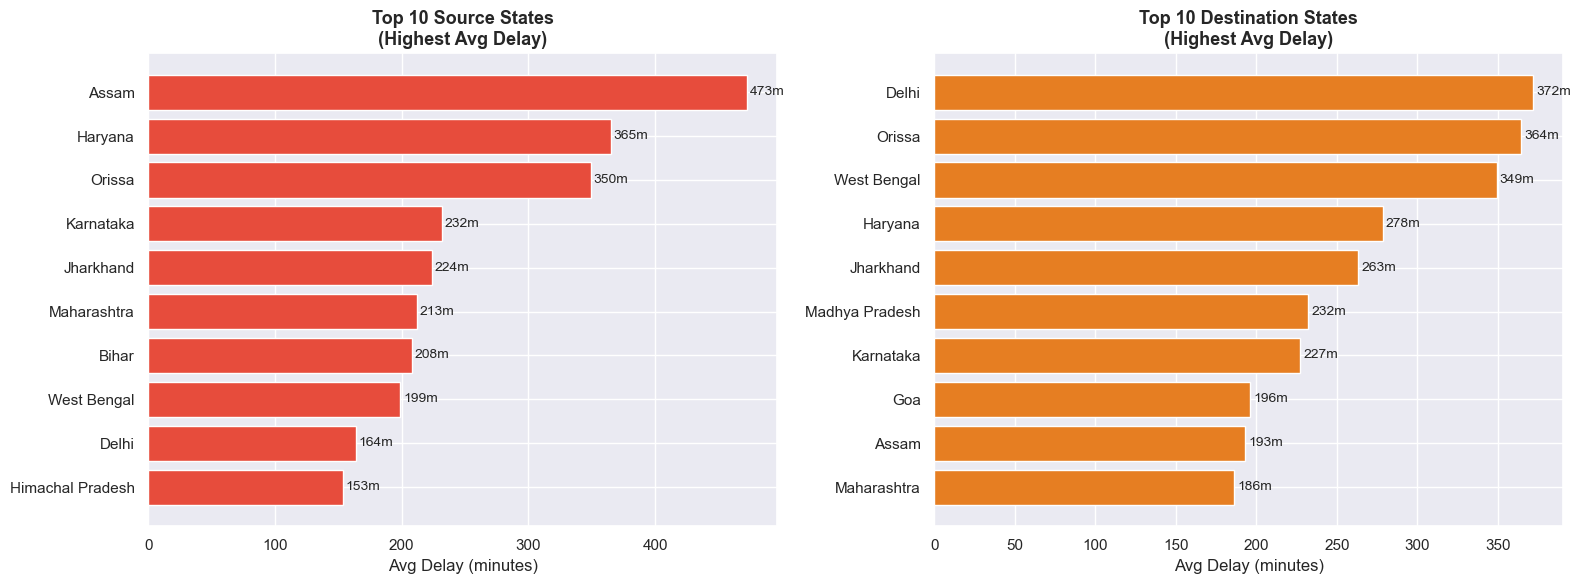

✅ Chart 3 saved!


In [ ]:
# --- CHART 4: Top 10 States by Avg Delay ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 source states with highest avg delay
top_source = (df.groupby('source_state')['delay_minutes']
               .agg(['mean', 'count'])
               .query('count >= 500')          # min 500 trips for reliability
               .sort_values('mean', ascending=False)
               .head(10)
               .reset_index())

axes[0].barh(top_source['source_state'], top_source['mean'],
              color='#E74C3C', edgecolor='white')
axes[0].set_title('Top 10 Source States\n(Highest Avg Delay)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Avg Delay (minutes)')
axes[0].invert_yaxis()
for i, v in enumerate(top_source['mean']):
    axes[0].text(v + 2, i, f'{v:.0f}m', va='center', fontsize=10)

# Top 10 destination states with highest avg delay
top_dest = (df.groupby('destination_state')['delay_minutes']
              .agg(['mean', 'count'])
              .query('count >= 500')
              .sort_values('mean', ascending=False)
              .head(10)
              .reset_index())

axes[1].barh(top_dest['destination_state'], top_dest['mean'],
              color='#E67E22', edgecolor='white')
axes[1].set_title('Top 10 Destination States\n(Highest Avg Delay)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Avg Delay (minutes)')
axes[1].invert_yaxis()
for i, v in enumerate(top_dest['mean']):
    axes[1].text(v + 2, i, f'{v:.0f}m', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/raw/chart3_state_delays.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

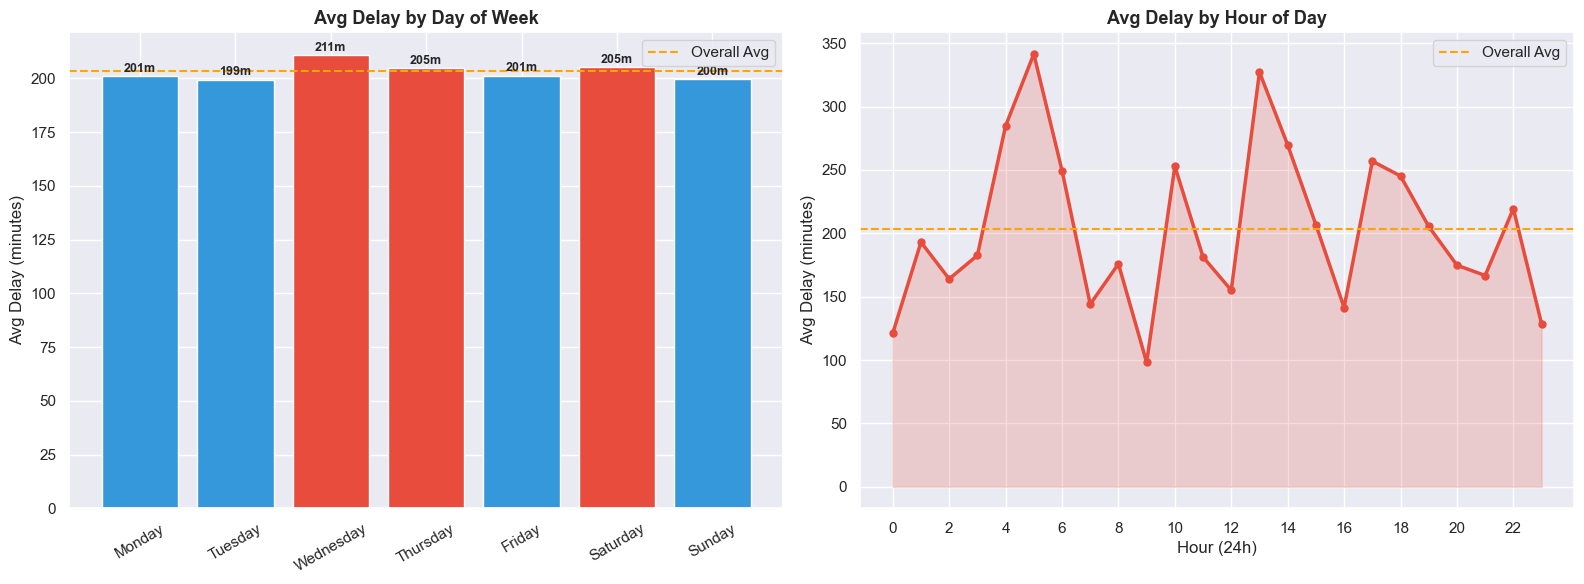

✅ Chart 4 saved!


In [ ]:
# --- CHART 4: Delay by Day of Week & Hour ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Day of week order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_delay = (df.groupby('day_of_week')['delay_minutes']
               .mean()
               .reindex(day_order)
               .reset_index())

colors_day = ['#E74C3C' if x >= day_delay['delay_minutes'].mean() 
              else '#3498DB' for x in day_delay['delay_minutes']]

axes[0].bar(day_delay['day_of_week'], day_delay['delay_minutes'],
            color=colors_day, edgecolor='white')
axes[0].set_title('Avg Delay by Day of Week', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Avg Delay (minutes)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(day_delay['delay_minutes'].mean(), color='orange',
                linestyle='--', label='Overall Avg')
axes[0].legend()
for i, v in enumerate(day_delay['delay_minutes']):
    axes[0].text(i, v + 2, f'{v:.0f}m', ha='center', fontsize=9, fontweight='bold')

# Hour of day
hour_delay = df.groupby('hour')['delay_minutes'].mean().reset_index()
axes[1].plot(hour_delay['hour'], hour_delay['delay_minutes'],
             color='#E74C3C', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(hour_delay['hour'], hour_delay['delay_minutes'],
                      alpha=0.2, color='#E74C3C')
axes[1].set_title('Avg Delay by Hour of Day', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Avg Delay (minutes)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].axhline(hour_delay['delay_minutes'].mean(), color='orange',
                linestyle='--', label='Overall Avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/raw/chart4_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

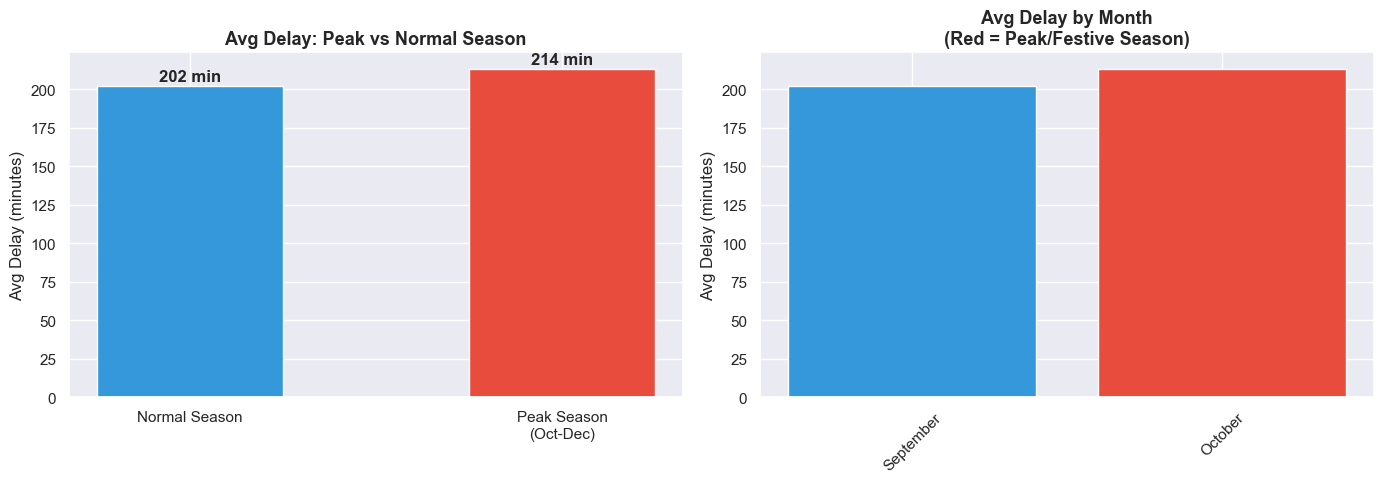

✅ Chart 5 saved!


In [ ]:
# --- CHART 5: Peak Season vs Normal ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak vs non-peak delay
season_data = df.groupby('is_peak_season').agg(
    avg_delay=('delay_minutes', 'mean'),
    delay_rate=('is_delayed', 'mean'),
    trip_count=('trip_uuid', 'count')
).reset_index()
season_data['Season'] = season_data['is_peak_season'].map(
    {True: 'Peak Season\n(Oct-Dec)', False: 'Normal Season'}
)
season_data['delay_rate'] = season_data['delay_rate'] * 100

bars = axes[0].bar(season_data['Season'], season_data['avg_delay'],
                    color=['#3498DB', '#E74C3C'], width=0.5, edgecolor='white')
axes[0].set_title('Avg Delay: Peak vs Normal Season', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Avg Delay (minutes)')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{bar.get_height():.0f} min', ha='center', fontweight='bold')

# Monthly trend
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_delay = (df.groupby('month_name')['delay_minutes']
                 .mean()
                 .reindex(month_order)
                 .dropna()
                 .reset_index())

bar_colors = ['#E74C3C' if m in ['October','November','December'] 
              else '#3498DB' for m in month_delay['month_name']]
axes[1].bar(month_delay['month_name'], month_delay['delay_minutes'],
            color=bar_colors, edgecolor='white')
axes[1].set_title('Avg Delay by Month\n(Red = Peak/Festive Season)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Avg Delay (minutes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/raw/chart5_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

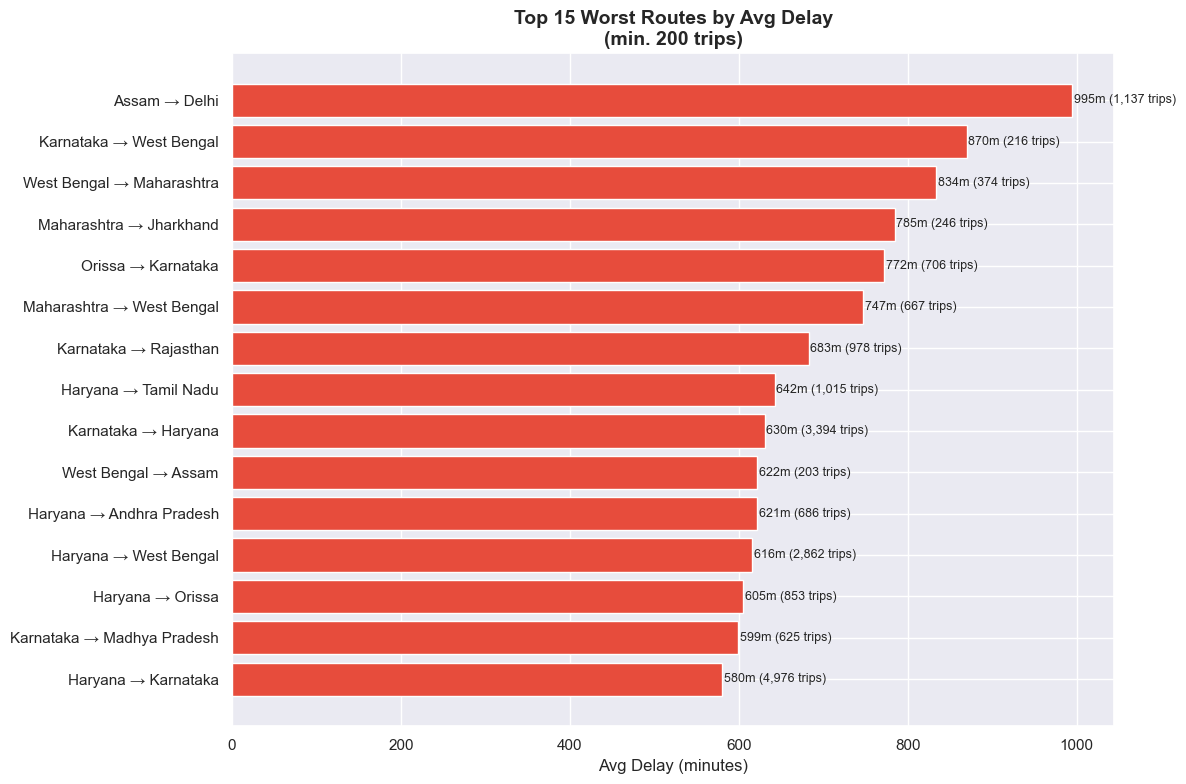

✅ Chart 6 saved!


In [ ]:
# --- CHART 6: Top 15 Worst Routes ---
worst_routes = (df.groupby('route')['delay_minutes']
                  .agg(['mean', 'count'])
                  .query('count >= 200')
                  .sort_values('mean', ascending=False)
                  .head(15)
                  .reset_index())

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(worst_routes['route'], worst_routes['mean'],
               color='#E74C3C', edgecolor='white')
ax.set_title('Top 15 Worst Routes by Avg Delay\n(min. 200 trips)', 
             fontweight='bold', fontsize=14)
ax.set_xlabel('Avg Delay (minutes)')
ax.invert_yaxis()
for i, (v, c) in enumerate(zip(worst_routes['mean'], worst_routes['count'])):
    ax.text(v + 2, i, f'{v:.0f}m ({c:,} trips)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/raw/chart6_worst_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

###  ========SQL ANALYSIS=====

In [ ]:
# ============================================
# PHASE 4: SQL ANALYSIS
# ============================================

import sqlite3

# Create SQLite database in memory and load our clean data
conn = sqlite3.connect('../data/raw/delhivery_analysis.db')
df.to_sql('shipments', conn, if_exists='replace', index=False)
print("✅ Data loaded into SQLite database!")
print(f"   Table: shipments | Rows: {len(df):,}")

✅ Data loaded into SQLite database!
   Table: shipments | Rows: 144,316


In [ ]:
# Helper function to run SQL and show results nicely
def run_query(sql, title=""):
    result = pd.read_sql_query(sql, conn)
    if title:
        print(f"\n{'='*50}")
        print(f"  {title}")
        print(f"{'='*50}")
    print(result.to_string(index=False))
    return result

# --- QUERY 1: Executive KPI Summary ---
kpi_summary = run_query("""
    SELECT 
        COUNT(*)                                        AS total_trips,
        ROUND(AVG(actual_time), 1)                      AS avg_actual_time_mins,
        ROUND(AVG(osrm_time), 1)                        AS avg_predicted_time_mins,
        ROUND(AVG(delay_minutes), 1)                    AS avg_delay_mins,
        ROUND(AVG(delay_minutes) / 60.0, 2)             AS avg_delay_hours,
        ROUND(SUM(CASE WHEN is_delayed=1 THEN 1.0 
                  ELSE 0 END) / COUNT(*) * 100, 1)      AS delay_rate_pct,
        ROUND(AVG(actual_distance_to_destination), 1)   AS avg_distance_km
    FROM shipments
""", "QUERY 1: Executive KPI Dashboard")


  QUERY 1: Executive KPI Dashboard
 total_trips  avg_actual_time_mins  avg_predicted_time_mins  avg_delay_mins  avg_delay_hours  delay_rate_pct  avg_distance_km
      144316                418.00                   214.40          203.60             3.39           88.00           234.70


In [ ]:
# --- QUERY 2: Delay by Route Type ---
run_query("""
    SELECT 
        route_type,
        COUNT(*)                                            AS total_trips,
        ROUND(AVG(delay_minutes), 1)                        AS avg_delay_mins,
        ROUND(SUM(CASE WHEN is_delayed=1 THEN 1.0 
                  ELSE 0 END) / COUNT(*) * 100, 1)          AS delay_rate_pct,
        ROUND(AVG(actual_distance_to_destination), 1)       AS avg_distance_km,
        ROUND(MIN(delay_minutes), 1)                        AS min_delay,
        ROUND(MAX(delay_minutes), 1)                        AS max_delay
    FROM shipments
    GROUP BY route_type
    ORDER BY avg_delay_mins DESC
""", "QUERY 2: Performance by Route Type (FTL vs Carting)")

# --- QUERY 3: Top 10 Worst Source States ---
run_query("""
    SELECT 
        source_state,
        COUNT(*)                                            AS trips_originated,
        ROUND(AVG(delay_minutes), 1)                        AS avg_delay_mins,
        ROUND(SUM(CASE WHEN is_delayed=1 THEN 1.0 
                  ELSE 0 END) / COUNT(*) * 100, 1)          AS delay_rate_pct,
        ROUND(AVG(actual_distance_to_destination), 1)       AS avg_distance_km
    FROM shipments
    WHERE source_state IS NOT NULL
    GROUP BY source_state
    HAVING trips_originated >= 500
    ORDER BY avg_delay_mins DESC
    LIMIT 10
""", "QUERY 3: Top 10 Worst Source States")


  QUERY 2: Performance by Route Type (FTL vs Carting)
route_type  total_trips  avg_delay_mins  delay_rate_pct  avg_distance_km  min_delay  max_delay
       FTL        99132          278.00           94.30           329.60    -110.00    3137.00
   Carting        45184           40.20           74.20            26.60     -71.00    2618.00

  QUERY 3: Top 10 Worst Source States
    source_state  trips_originated  avg_delay_mins  delay_rate_pct  avg_distance_km
           Assam              2875          472.80           93.20           337.10
         Haryana             27408          365.40           93.50           464.60
          Orissa              2094          349.60           95.50           292.40
       Karnataka             19562          231.90           83.30           292.70
       Jharkhand              2597          224.20           95.10           263.90
     Maharashtra             21401          212.50           94.30           244.40
           Bihar              416

,source_state,trips_originated,avg_delay_mins,delay_rate_pct,avg_distance_km
0,Assam,2875,472.80,93.20,337.10
1,Haryana,27408,365.40,93.50,464.60
2,Orissa,2094,349.60,95.50,292.40
3,Karnataka,19562,231.90,83.30,292.70
4,Jharkhand,2597,224.20,95.10,263.90
5,Maharashtra,21401,212.50,94.30,244.40
6,Bihar,4166,207.90,95.00,193.80
7,West Bengal,5963,199.10,92.80,183.00
8,Delhi,4382,164.10,79.70,165.70
9,Himachal Pradesh,587,153.50,87.10,57.20


In [ ]:
# Export all key aggregations as CSVs for Tableau
# Tableau works best with pre-aggregated clean tables

# 1. State-level summary
state_summary = pd.read_sql_query("""
    SELECT 
        source_state AS state,
        COUNT(*) AS total_trips,
        ROUND(AVG(delay_minutes), 1) AS avg_delay_mins,
        ROUND(SUM(CASE WHEN is_delayed=1 THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS delay_rate_pct,
        ROUND(AVG(actual_distance_to_destination),1) AS avg_distance_km
    FROM shipments
    WHERE source_state IS NOT NULL
    GROUP BY source_state
    HAVING total_trips >= 100
""", conn)
state_summary.to_csv('../data/raw/tableau_state_summary.csv', index=False)

# 2. Route summary
route_summary = pd.read_sql_query("""
    SELECT route, source_state, destination_state,
        COUNT(*) AS total_trips,
        ROUND(AVG(delay_minutes),1) AS avg_delay_mins,
        ROUND(SUM(CASE WHEN is_delayed=1 THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS delay_rate_pct,
        ROUND(AVG(delay_minutes)*COUNT(*)/1000.0,0) AS impact_score
    FROM shipments
    WHERE route IS NOT NULL
    GROUP BY route
    HAVING total_trips >= 100
""", conn)
route_summary.to_csv('../data/raw/tableau_route_summary.csv', index=False)

# 3. Hour summary
hour_summary = pd.read_sql_query("""
    SELECT hour, route_type,
        COUNT(*) AS total_trips,
        ROUND(AVG(delay_minutes),1) AS avg_delay_mins,
        ROUND(SUM(CASE WHEN is_delayed=1 THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS delay_rate_pct
    FROM shipments
    GROUP BY hour, route_type
""", conn)
hour_summary.to_csv('../data/raw/tableau_hour_summary.csv', index=False)

conn.close()
print("✅ All SQL queries complete!")
print("✅ 3 Tableau-ready CSV files exported:")
print("   → tableau_state_summary.csv")
print("   → tableau_route_summary.csv")
print("   → tableau_hour_summary.csv")

✅ All SQL queries complete!
✅ 3 Tableau-ready CSV files exported:
   → tableau_state_summary.csv
   → tableau_route_summary.csv
   → tableau_hour_summary.csv


In [2]:
# ============================================
# GENERATE STATS FOR README
# ============================================

df = pd.read_csv('../data/cleaned/delhivery_clean.csv')

worst_route = (df.groupby('route')['delay_minutes']
               .agg(['mean','count'])
               .query('count >= 200')
               .sort_values('mean', ascending=False)
               .head(1))

best_route = (df.groupby('route')['delay_minutes']
              .agg(['mean','count'])
              .query('count >= 200')
              .sort_values('mean', ascending=True)
              .head(1))

print(f"Total Shipments: {len(df):,}")
print(f"Delayed Shipments: {df['is_delayed'].sum():,} ({df['is_delayed'].mean()*100:.1f}%)")
print(f"Avg Delay: {df['delay_minutes'].mean():.0f} minutes ({df['delay_minutes'].mean()/60:.1f} hours)")
print(f"Worst Route: {worst_route.index[0]} — {worst_route['mean'].values[0]:.0f} min delay")
print(f"Best Route: {best_route.index[0]} — {best_route['mean'].values[0]:.0f} min delay")
print(f"FTL Delay Rate: {df[df['route_type']=='FTL']['is_delayed'].mean()*100:.1f}%")
print(f"Carting Delay Rate: {df[df['route_type']=='Carting']['is_delayed'].mean()*100:.1f}%")
print(f"Worst State: {df.groupby('source_state')['delay_minutes'].mean().idxmax()}")

Total Shipments: 144,316
Delayed Shipments: 127,022 (88.0%)
Avg Delay: 204 minutes (3.4 hours)
Worst Route: Assam → Delhi — 995 min delay
Best Route: Punjab → Chandigarh — 20 min delay
FTL Delay Rate: 94.3%
Carting Delay Rate: 74.2%
Worst State: Assam
